# LAB 10 - Variacioni i Kohës së Ekzekutimit

## 1. Qëllimi i laboratorit

Qëllimi i këtij laboratori është të studiohet variacioni i kohës së ekzekutimit të një algoritmi kur madhësia e hyrjes mbahet konstante.

Në laboratorin e mëparshëm u analizua si ndryshon koha e ekzekutimit kur ndryshon madhësia e hyrjes $n$.  
Në këtë laborator, madhësia e hyrjes mbahet e pandryshuar dhe algoritmi ekzekutohet shumë herë.

Kjo bëhet për të parë nëse koha e ekzekutimit është gjithmonë e njëjtë apo ndryshon nga një matje në tjetrën.

---

## 2. Teoria

Edhe kur ekzekutohet i njëjti algoritëm me të njëjtën madhësi hyrjeje, koha e ekzekutimit nuk është gjithmonë saktësisht e njëjtë.

Kjo ndodh sepse kompjuteri ndikohet nga faktorë të ndryshëm, si:

- proceset që punojnë në sfond;
- sistemi operativ;
- përdorimi i procesorit;
- memoria cache;
- menaxhimi i energjisë;
- ngarkesa e përgjithshme e kompjuterit.

Për këtë arsye, koha e ekzekutimit mund të trajtohet si një madhësi eksperimentale me pasiguri.

Nëse kemi disa matje të kohës:

$$
T_1, T_2, T_3, \ldots, T_N
$$

atëherë koha mesatare llogaritet me formulën:

$$
\bar{T} = \frac{1}{N}\sum_{i=1}^{N}T_i
$$

Devijimi standard llogaritet me formulën:

$$
\sigma = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N}(T_i-\bar{T})^2}
$$

Rezultati përfundimtar jepet në formën:

$$
T = (\bar{T} \pm \sigma)
$$

---

## 3. Algoritmi i përdorur

Në këtë laborator përdoret algoritmi i shumës së elementeve të një liste.

Algoritmi është:

```python
total = 0

for x in data:
    total += x

Rezultatet për LAB10
--------------------
Numri i matjeve = 100
Madhësia e hyrjes n = 100000

Statistikat:
Koha mesatare = 0.01255150 s
Devijimi standard = 0.00241273 s
Koha minimale = 0.00954100 s
Koha maksimale = 0.01914750 s

Rezultati përfundimtar:
T = (0.01255150 ± 0.00241273) s

10 matjet e para:
[0.0127559 0.0113291 0.0108784 0.0142049 0.0134546 0.0109918 0.0120217
 0.0134717 0.0108409 0.01157  ]


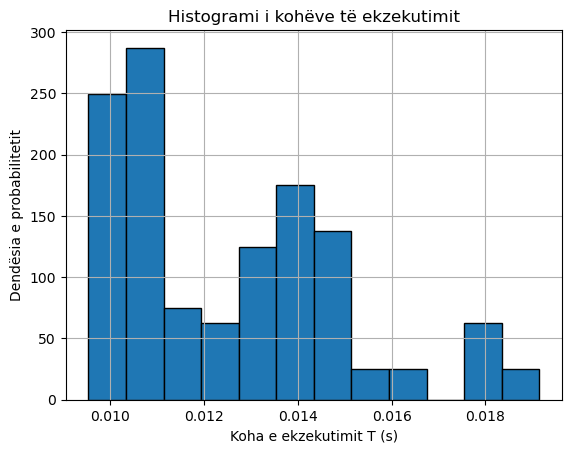

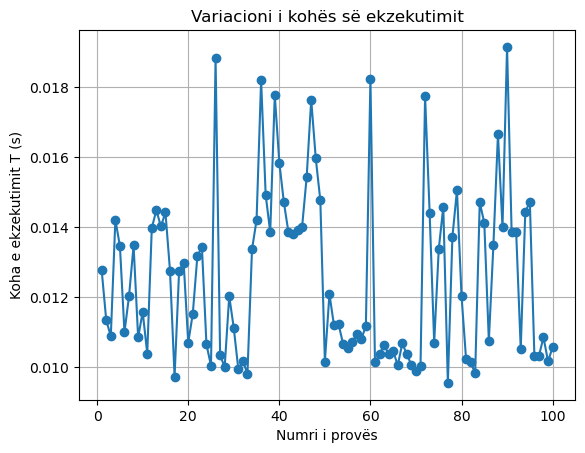

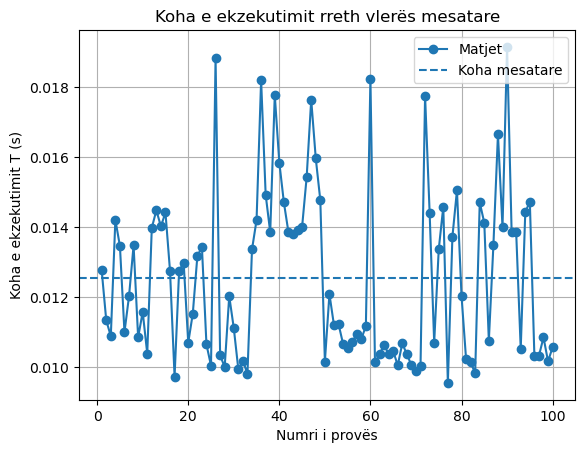

In [3]:

import time
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Algoritmi: Shuma e elementeve
# -----------------------------

def sum_algorithm(data):
    total = 0
    
    for x in data:
        total += x
    
    return total


# -----------------------------
# Madhësia fikse e hyrjes
# -----------------------------

n = 100000

# Krijimi i të dhënave
data = np.random.randint(0, 100, size=n)


# -----------------------------
# Funksioni për matjen e kohës
# -----------------------------

def measure():
    start = time.perf_counter()
    sum_algorithm(data)
    end = time.perf_counter()
    
    return end - start


# -----------------------------
# Ekzekutimi 100 herë
# -----------------------------

N = 100

times = []

for _ in range(N):
    T = measure()
    times.append(T)

times = np.array(times)


# -----------------------------
# Llogaritjet statistikore
# -----------------------------

mean_T = np.mean(times)
std_T = np.std(times, ddof=1)
min_T = np.min(times)
max_T = np.max(times)


# -----------------------------
# Printimi i rezultateve
# -----------------------------

print("Rezultatet për LAB10")
print("--------------------")
print(f"Numri i matjeve = {N}")
print(f"Madhësia e hyrjes n = {n}")

print("\nStatistikat:")
print(f"Koha mesatare = {mean_T:.8f} s")
print(f"Devijimi standard = {std_T:.8f} s")
print(f"Koha minimale = {min_T:.8f} s")
print(f"Koha maksimale = {max_T:.8f} s")

print("\nRezultati përfundimtar:")
print(f"T = ({mean_T:.8f} ± {std_T:.8f}) s")


# -----------------------------
# Printimi i disa matjeve
# -----------------------------

print("\n10 matjet e para:")
print(np.round(times[:10], 8))


# -----------------------------
# Histogrami i kohëve
# -----------------------------

plt.figure()
plt.hist(times, bins=12, density=True, edgecolor="black")
plt.xlabel("Koha e ekzekutimit T (s)")
plt.ylabel("Dendësia e probabilitetit")
plt.title("Histogrami i kohëve të ekzekutimit")
plt.grid(True)
plt.show()


# -----------------------------
# Grafiku i matjeve sipas provës
# -----------------------------

plt.figure()
plt.plot(range(1, N + 1), times, marker="o")
plt.xlabel("Numri i provës")
plt.ylabel("Koha e ekzekutimit T (s)")
plt.title("Variacioni i kohës së ekzekutimit")
plt.grid(True)
plt.show()
# ------------------------------
# Krahasimi me vleren mesatare
# ------------------------------
plt.figure()
plt.plot(range(1, N + 1), times, marker="o", label="Matjet")
plt.axhline(mean_T, linestyle="--", label="Koha mesatare")

plt.xlabel("Numri i provës")
plt.ylabel("Koha e ekzekutimit T (s)")
plt.title("Koha e ekzekutimit rreth vlerës mesatare")
plt.grid(True)
plt.legend()
plt.show()